In [12]:
import json
import pandas as pd

In [13]:
import numpy as np
from scipy import stats

def summarize_results(results: dict, model: str):
    # Collect metrics across runs
    balanced_accs = []
    f1_liegen = []
    f1_stehen = []
    f1_macro = []  # average of both classes' F1
    run_ids = []

    for run_id, run_data in results.items():
        metrics = run_data["Metrics"][model]

        balanced_accs.append(metrics["balanced_accuracy"])
        f1_liegen.append(metrics["F1 Score Liegen"])
        f1_stehen.append(metrics["F1 Score Stehen"])
        f1_macro.append((metrics["F1 Score Liegen"] + metrics["F1 Score Stehen"]) / 2)
        run_ids.append(run_id)

    def mean_std_ci(values):
        n = len(values)
        mean = np.mean(values)
        std = np.std(values, ddof=1)  # sample std
        # t critical value for 95% CI
        t_crit = stats.t.ppf(0.975, df=n-1)
        ci_margin = t_crit * std / np.sqrt(n)
        return mean, std, (mean - ci_margin, mean + ci_margin)

    summary = {
        "Balanced Accuracy": mean_std_ci(balanced_accs),
        "F1 (Liegen)": mean_std_ci(f1_liegen),
        "F1 (Stehen)": mean_std_ci(f1_stehen),
        "Macro-F1": mean_std_ci(f1_macro),
    }

    print(f"Model: {model}")

    # Pretty print
    for metric, (mean, std, ci) in summary.items():
        print(f"{metric}: {mean:.2f} ± {std:.2f} (95% CI: {ci[0]:.2f} – {ci[1]:.2f})")

    # Find the run with the median macro-F1
    macro_f1_arr = np.array(f1_macro)
    median_idx = int(np.argsort(macro_f1_arr)[len(macro_f1_arr)//2])
    median_run_id = run_ids[median_idx]
    median_macro_f1 = macro_f1_arr[median_idx]
    print(f"Run with median Macro-F1: {median_run_id} (Macro-F1: {median_macro_f1:.3f})")

    # return summary

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def prepare_metric_dataframe(results: dict, model: str = 'rf'):
    """Convert results dict into a tidy DataFrame with run × metric values."""
    records = []
    for run_id, run_data in results.items():
        metrics = run_data["Metrics"][model]

        f1_liegen = metrics["F1 Score Liegen"]
        f1_stehen = metrics["F1 Score Stehen"]
        macro_f1 = (f1_liegen + f1_stehen) / 2

        records.append({
            "run": run_id,
            "Balanced Accuracy": metrics["balanced_accuracy"],
            "F1 (Liegen)": f1_liegen,
            "F1 (Stehen)": f1_stehen,
            "Macro-F1": macro_f1
        })
    df = pd.DataFrame(records)
    return df

def plot_results(results: dict):
    df = prepare_metric_dataframe(results)

    # Melt into long format for easier plotting
    df_long = df.melt(id_vars="run", var_name="Metric", value_name="Score")

    # --- 1. Boxplot for distribution across runs ---
    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    df_long.boxplot(column="Score", by="Metric", ax=ax)
    plt.title("")
    plt.suptitle("")  # remove default title
    plt.ylabel("Score")
    plt.xticks()
    plt.show()

    # --- 2. Bar chart with 95% CI ---
    means = df_long.groupby("Metric")["Score"].mean()
    stds = df_long.groupby("Metric")["Score"].std(ddof=1)
    n = df["run"].nunique()
    t_crit = stats.t.ppf(0.975, df=n-1)
    ci_margin = t_crit * stds / np.sqrt(n)

    plt.figure(figsize=(8, 5))
    ax = plt.gca()
    ax.bar(means.index, means.values, yerr=ci_margin.values, capsize=5, color="skyblue")
    plt.title("")
    plt.ylabel("Score")
    plt.xticks()
    plt.show()


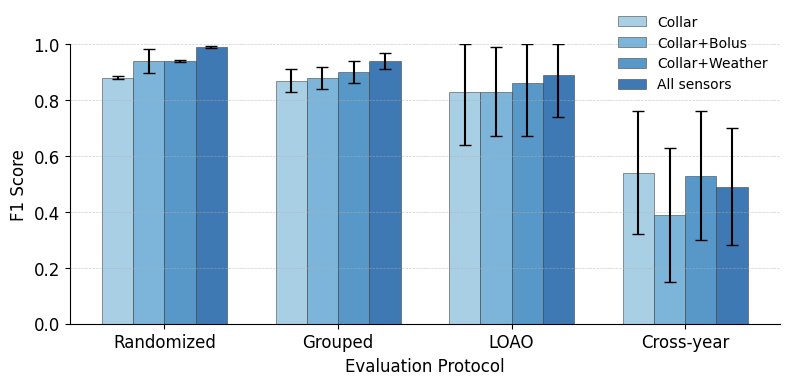

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# -----------------------
# Data
# -----------------------

protocols = ["Randomized", "Grouped", "LOAO", "Cross-year"]
feature_sets = ["Collar", "Collar+Bolus", "Collar+Weather", "All sensors"]

means = np.array([
    [0.88, 0.94, 0.94, 0.99],
    [0.87, 0.88, 0.90, 0.94],
    [0.83, 0.83, 0.86, 0.89],
    [0.54, 0.39, 0.53, 0.49],
])

stds = np.array([
    [0.005, 0.044, 0.003, 0.002],
    [0.04, 0.04, 0.04, 0.03],
    [0.19, 0.16, 0.19, 0.15],
    [0.22, 0.24, 0.23, 0.21],
])

upper = np.minimum(means + stds, 1.0)
lower = np.maximum(means - stds, 0.0)

yerr = np.array([means - lower, upper - means])
# -----------------------
# Monochrome palette (light → dark)
# -----------------------

colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(feature_sets)))

# -----------------------
# Plot
# -----------------------

x = np.arange(len(protocols))
width = 0.18

fig, ax = plt.subplots(figsize=(8, 4))

hatches = ["", "", "o",  "x"]

for i in range(len(feature_sets)):
    ax.bar(
        x + i * width,
        means[:, i],
        width,
        yerr=yerr[:, :, i],
        capsize=4,
        color=colors[i],          # can even make all bars same color
        edgecolor="#444444",
        linewidth=0.5,
        label=feature_sets[i],
        alpha=0.8,
    )

# -----------------------
# Formatting
# -----------------------

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(protocols, fontsize=12)

ax.set_ylabel("F1 Score", fontsize=12)
ax.set_xlabel("Evaluation Protocol", fontsize=12)
ax.set_ylim(0, 1.0)
ax.tick_params(axis='y', labelsize=12)

# Legend (top-right, no overlap)
ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(1.00, 1.15),
    title=None
)

ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)
ax.grid(axis='x', visible=False)

# clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

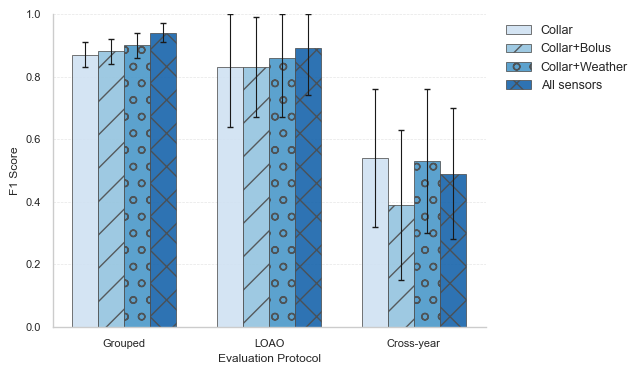

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------
# Style (tight + compact)
# -----------------------
sns.set_theme(style="whitegrid", context="paper", font_scale=0.9)

# -----------------------
# Data
# -----------------------
protocols = ["Grouped", "LOAO", "Cross-year"]
feature_sets = ["Collar", "Collar+Bolus", "Collar+Weather", "All sensors"]

means = np.array([
    [0.87, 0.88, 0.90, 0.94],
    [0.83, 0.83, 0.86, 0.89],
    [0.54, 0.39, 0.53, 0.49],
])

stds = np.array([
    [0.04, 0.04, 0.04, 0.03],
    [0.19, 0.16, 0.19, 0.15],
    [0.22, 0.24, 0.23, 0.21],
])

upper = np.minimum(means + stds, 1.0)
lower = np.maximum(means - stds, 0.0)
yerr = np.array([means - lower, upper - means])

# -----------------------
# Colors
# -----------------------
colors = sns.color_palette("Blues", n_colors=len(feature_sets))

# -----------------------
# Plot
# -----------------------
x = np.arange(len(protocols))
width = 0.18

fig, ax = plt.subplots(figsize=(6.5, 3.8))  # 👈 tighter proportions

hatches = ["", "/", "o", "x"]

for i in range(len(feature_sets)):
    ax.bar(
        x + i * width,
        means[:, i],
        width,
        yerr=yerr[:, :, i],
        capsize=2,                      # thinner caps
        error_kw=dict(lw=0.8),          # 👈 thinner error bars
        color=colors[i],
        edgecolor="0.3",
        linewidth=0.6,
        hatch=hatches[i],
        alpha=0.9,
        label=feature_sets[i],
    )

# -----------------------
# Formatting
# -----------------------
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(protocols)

ax.set_ylabel("F1 Score")
ax.set_xlabel("Evaluation Protocol")
ax.set_ylim(0, 1.0)

# Legend (top-right, no overlap)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),   # 👈 outside plot
    frameon=False,
    fontsize=9,
    title=None
)

# subtle grid
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
ax.grid(axis='x', visible=False)

sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Experiment 2 results

In [27]:
exp_4_path = "/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/exp_5_FINAL_merged_collar_herde_weather_bolus_MARKOV/results_exp_5_FINAL_merged_collar_herde_weather_bolus_MARKOV.json"

with open(exp_4_path, "r") as f:
    exp_4_results = json.load(f)

summarize_results(exp_4_results, model="xgboost")

Model: xgboost
Balanced Accuracy: 0.96 ± 0.02 (95% CI: 0.95 – 0.97)
F1 (Liegen): 0.90 ± 0.06 (95% CI: 0.85 – 0.94)
F1 (Stehen): 0.97 ± 0.02 (95% CI: 0.96 – 0.98)
Macro-F1: 0.93 ± 0.04 (95% CI: 0.91 – 0.96)
Run with median Macro-F1: 46 (Macro-F1: 0.942)


In [28]:
from pathlib import Path


logo_baseline_path = "/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/logo/exp_1_FINAL_merged_collar_herde_weather_bolus/results.json"
logo_bolus_path = "/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/logo/exp_4_FINAL_merged_collar_herde_weather_bolus/results.json"
logo_weather_path = "/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/logo/exp_3_FINAL_merged_collar_herde_weather_bolus/results.json"
logo_all_path = "/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/logo/exp_5_FINAL_merged_collar_herde_weather_bolus/results.json"

def open_results(path):
    # -----------------------
    # Load LOGO per-cow results
    # -----------------------
    with open(path, "r") as f:
        results = json.load(f)

    res_rows = []
    for cow_id_str, m in results.items():
        row = {"cow_id": int(cow_id_str)}
        row.update(m)
        res_rows.append(row)

    res_df = pd.DataFrame(res_rows)

    # keep only the columns we care about (add others if you want)
    keep_cols = ["cow_id", "macro_f1", "balanced_accuracy", "f1_lying", "f1_standing",
                "support_lying", "support_standing"]
    keep_cols = [c for c in keep_cols if c in res_df.columns]
    res_df = res_df[keep_cols].copy()
    print(f"Macro F1 mean: {res_df.macro_f1.mean():.2f} ± {res_df.macro_f1.std():.2f}")
    print(f"F1 standing mean: {res_df.f1_standing.mean():.2f} ± {res_df.f1_standing.std():.2f}")
    print(f"F1 lying mean: {res_df.f1_lying.mean():.2f} ± {res_df.f1_lying.std():.2f}")
    print(f"Balanced Accuracy mean: {res_df.balanced_accuracy.mean():.2f} ± {res_df.balanced_accuracy.std():.2f}")
    return res_df

# logo_1_bolus_results = open_results(logo_baseline_path)
# logo_5_bolus_results = open_results(logo_all_sensors_path)

baseline_results = open_results(logo_baseline_path)
weather_results = open_results(logo_weather_path)
bolus_results = open_results(logo_bolus_path)
all_results = open_results(logo_all_path)


Macro F1 mean: 0.83 ± 0.19
F1 standing mean: 0.94 ± 0.12
F1 lying mean: 0.73 ± 0.31
Balanced Accuracy mean: 0.89 ± 0.14
Macro F1 mean: 0.86 ± 0.19
F1 standing mean: 0.95 ± 0.12
F1 lying mean: 0.77 ± 0.32
Balanced Accuracy mean: 0.90 ± 0.16
Macro F1 mean: 0.83 ± 0.16
F1 standing mean: 0.95 ± 0.05
F1 lying mean: 0.70 ± 0.30
Balanced Accuracy mean: 0.87 ± 0.14
Macro F1 mean: 0.89 ± 0.15
F1 standing mean: 0.96 ± 0.12
F1 lying mean: 0.81 ± 0.27
Balanced Accuracy mean: 0.93 ± 0.11


/var/folders/r_/cnfqbwmx0kn_4s0yzfm9fxdh0000gn/T/ipykernel_21517/3492971971.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=names, showfliers=False, medianprops=medianprops)


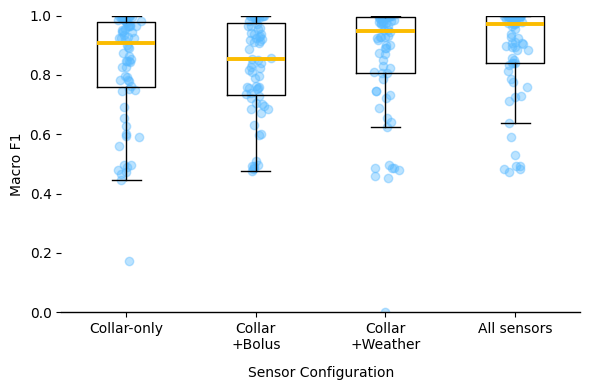

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Prepare data
# -----------------------
datasets = [baseline_results, bolus_results, weather_results, all_results]
names = ["Collar-only", "Collar\n+Bolus", "Collar\n+Weather", "All sensors"]

vals, xs = [], []

# Blue palette
palette = ["#57B9FF", "#57B9FF", "#57B9FF", "#57B9FF"]

for i, df in enumerate(datasets):
    vals.append(df['macro_f1'].values)
    # jitter for scatter
    xs.append(np.random.normal(i + 1, 0.04, df['macro_f1'].values.shape[0]))


# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(6,4))
medianprops = dict(color="#FBBC01", linewidth=2.8)  # thicker median

plt.boxplot(vals, labels=names, showfliers=False, medianprops=medianprops)

# Overlay individual points
for x, val, c in zip(xs, vals, palette):
    plt.scatter(x, val, alpha=0.4, color=c)

# Labels
plt.ylabel("Macro F1")
plt.ylim(0, 1)

plt.xlabel("Sensor Configuration", labelpad=10)

# -----------------------
# Cleaner background
# -----------------------
ax = plt.gca()
ax.grid(False)  # remove grid
ax.set_facecolor("white")  # white background
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)

plt.tight_layout()
plt.show()

/var/folders/r_/cnfqbwmx0kn_4s0yzfm9fxdh0000gn/T/ipykernel_21517/2246375442.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=names, showfliers=False, medianprops=medianprops)


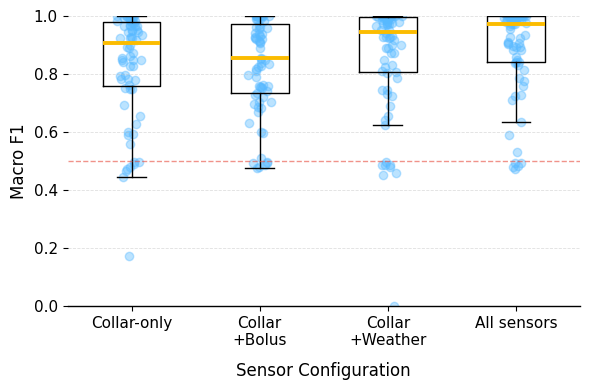

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Prepare data
# -----------------------
datasets = [baseline_results, bolus_results, weather_results, all_results]
names = ["Collar-only", "Collar\n+Bolus", "Collar\n+Weather", "All sensors"]

vals, xs = [], []

palette = ["#57B9FF"] * 4

for i, df in enumerate(datasets):
    vals.append(df['macro_f1'].values)
    xs.append(np.random.normal(i + 1, 0.04, df['macro_f1'].values.shape[0]))

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(6,4))

medianprops = dict(color="#FBBC01", linewidth=2.8)

plt.boxplot(vals, labels=names, showfliers=False, medianprops=medianprops)

# Scatter points
for x, val, c in zip(xs, vals, palette):
    plt.scatter(x, val, alpha=0.4, color=c)

# Labels
plt.ylabel("Macro F1", fontsize=12)
plt.ylim(0, 1)

# -----------------------
# Background styling
# -----------------------
ax = plt.gca()

# Light horizontal grid at y-ticks
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
ax.grid(axis='x', visible=False)

# Chance level line
ax.axhline(0.5, color="#e74c3c", linestyle='--', linewidth=1, alpha=0.6)
plt.xlabel("Sensor Configuration", labelpad=10, fontsize=12)

ax.tick_params(axis='both', labelsize=11)
# Clean spines
ax.set_facecolor("white")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.0)

plt.tight_layout()
plt.show()

In [76]:
for n in range(1,df.columns.shape[0]+1):
    df.rename(columns={f"data{n}": f"Experiment {n}"}, inplace=True)
df.head()

,Experiment 1,Experiment 2,Experiment 3,Experiment 4
0,76.630194,85.163937,91.021984,83.175413
1,91.524420,79.605182,77.279063,86.139952
2,67.806583,89.745290,92.252631,89.688156
3,92.551233,75.286113,94.732170,89.388444
4,74.853860,63.781988,94.262345,66.650315


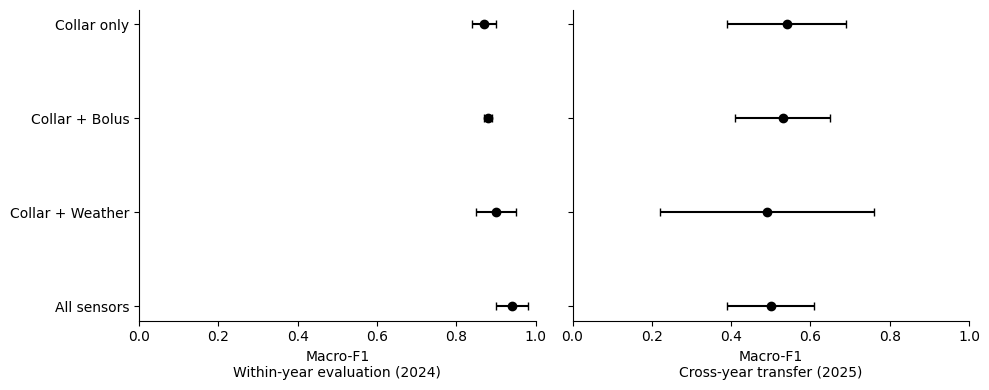

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Example structure (adapt to your data)
# -----------------------
labels = ["Collar only", "Collar + Bolus", "Collar + Weather", "All sensors"]

# Replace these with your actual aggregated values
within_means = [0.87, 0.88, 0.90, 0.94]
within_std   = [0.03, 0.01, 0.05, 0.04]

cross_means = [0.54, 0.53, 0.49, 0.50]
cross_std   = [0.15, 0.12, 0.27, 0.11]

y_pos = np.arange(len(labels))

# -----------------------
# Plot
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# ---- Left: within-year ----
ax = axes[0]
ax.errorbar(within_means, y_pos, xerr=within_std,
            fmt='o', color='black', ecolor='black',
            capsize=3)

ax.set_xlabel("Macro-F1\nWithin-year evaluation (2024)")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlim(0.0, 1.0)

# ---- Right: cross-year ----
ax = axes[1]
ax.errorbar(cross_means, y_pos, xerr=cross_std,
            fmt='o', color='black', ecolor='black',
            capsize=3)

ax.set_xlabel("Macro-F1\nCross-year transfer (2025)")
ax.set_xlim(0.0, 1.0)

# -----------------------
# Clean style (like your sketch)
# -----------------------
for ax in axes:
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

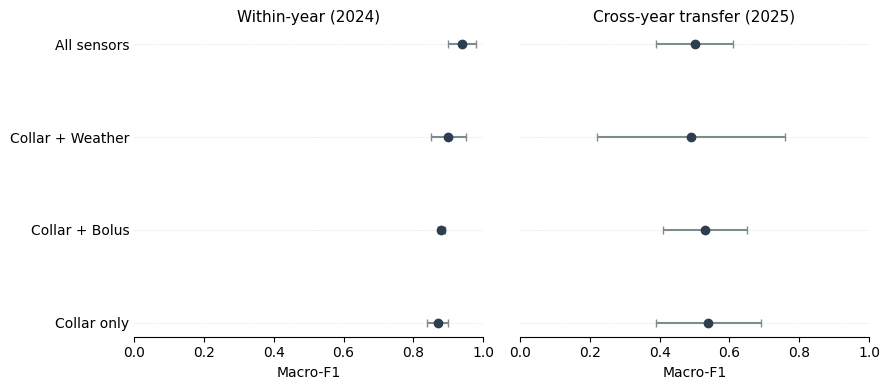

In [9]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Collar only", "Collar + Bolus", "Collar + Weather", "All sensors"]

within_means = [0.87, 0.88, 0.90, 0.94]
within_std   = [0.03, 0.01, 0.05, 0.04]

cross_means = [0.54, 0.53, 0.49, 0.50]
cross_std   = [0.15, 0.12, 0.27, 0.11]

y_pos = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

color = "#2c3e50"  # softer than black

# ---- Left ----
ax = axes[0]
ax.errorbar(within_means, y_pos, xerr=within_std,
            fmt='o',
            color=color,
            ecolor="#7f8c8d",   # lighter error bars
            elinewidth=1.5,
            capsize=3,
            markersize=6)

ax.set_title("Within-year (2024)", fontsize=11)
ax.set_xlabel("Macro-F1")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlim(0.0, 1.0)
ax.invert_yaxis()  # <-- reverse order

# ---- Right ----
ax = axes[1]
ax.errorbar(cross_means, y_pos, xerr=cross_std,
            fmt='o',
            color=color,
            ecolor="#7f8c8d",
            elinewidth=1.5,
            capsize=3,
            markersize=6)

ax.set_title("Cross-year transfer (2025)", fontsize=11)
ax.set_xlabel("Macro-F1")
ax.set_xlim(0.0, 1.0)
ax.invert_yaxis()

# -----------------------
# Modern styling
# -----------------------
for ax in axes:
    # subtle horizontal guides
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.grid(axis='x', visible=False)

    # remove clutter
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.tick_params(axis='y', length=0)  # remove tick marks

plt.tight_layout()
plt.show()

/var/folders/r_/cnfqbwmx0kn_4s0yzfm9fxdh0000gn/T/ipykernel_75186/3633685623.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=names)


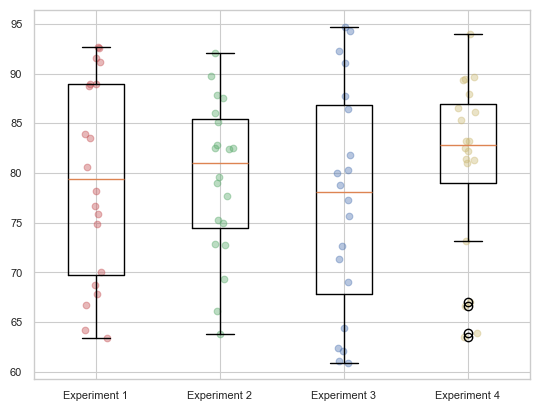

In [ ]:
vals, names, xs = [],[],[]
for i, col in enumerate(df.columns):
    vals.append(df[col].values)
    names.append(col)
    xs.append(np.random.normal(i + 1, 0.04, df[col].values.shape[0]))  # adds jitter to the data points - can be adjusted

plt.boxplot(vals, labels=names)
palette = ['r', 'g', 'b', 'y']
for x, val, c in zip(xs, vals, palette):
    plt.scatter(x, val, alpha=0.4, color=c)
plt.show()

In [7]:
import pandas as pd

def json_to_xgboost_df(results_json: dict) -> pd.DataFrame:
    rows = []

    for seed, seed_data in results_json.items():
        xgb_metrics = seed_data.get("Metrics", {}).get("xgboost", {})
        if not xgb_metrics:
            continue  # skip seeds without xgboost results

        row = {"seed": int(seed)}
        row.update(xgb_metrics)
        rows.append(row)

    return pd.DataFrame(rows)


# usage
# pooled_full_baseline = json_to_xgboost_df(full_baseline_results)
# pooled_full_weather = json_to_xgboost_df(full_weather_results)
# pooled_bolus_exp_1 = json_to_xgboost_df(bolus_exp_1)
# pooled_bolus_exp_5 = json_to_xgboost_df(bolus_exp_5)

grouped_baseline = json_to_xgboost_df(grouped_baseline_results)
grouped_collar_weather = json_to_xgboost_df(grouped_collar_weather_results)
grouped_collar_bolus = json_to_xgboost_df(grouped_collar_bolus_results)
grouped_all_sensors = json_to_xgboost_df(grouped_all_sensors_results)


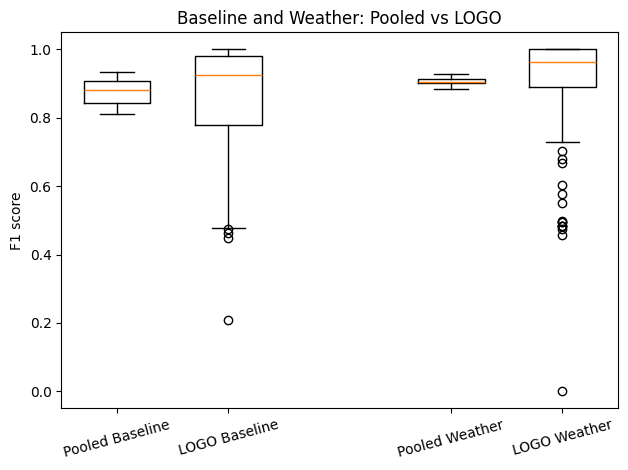

In [79]:
import matplotlib.pyplot as plt

# data
data_plot1 = [
    pooled_full_baseline["F1 Score Global"],
    logo_1_results["macro_f1"],
    pooled_full_weather["F1 Score Global"],
    logo_3_results["macro_f1"],
]

labels_plot1 = [
    "Pooled Baseline",
    "LOGO Baseline",
    "Pooled Weather",
    "LOGO Weather",
]

positions_plot1 = [1, 2, 4, 5]

plt.figure()
plt.boxplot(data_plot1, positions=positions_plot1, widths=0.6)
plt.xticks(positions_plot1, labels_plot1, rotation=15)
plt.ylabel("F1 score")
plt.title("Baseline and Weather: Pooled vs LOGO")
plt.tight_layout()
plt.show()


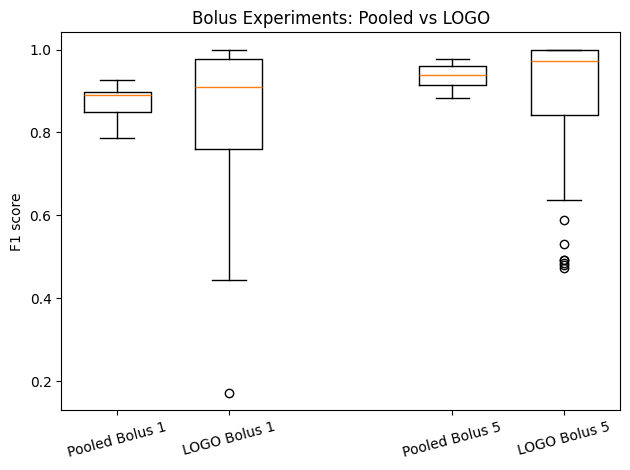

In [80]:
# data
data_plot2 = [
    pooled_bolus_exp_1["F1 Score Global"],
    logo_1_bolus_results["macro_f1"],
    pooled_bolus_exp_5["F1 Score Global"],
    logo_5_bolus_results["macro_f1"],
]

labels_plot2 = [
    "Pooled Bolus 1",
    "LOGO Bolus 1",
    "Pooled Bolus 5",
    "LOGO Bolus 5",
]

positions_plot2 = [1, 2, 4, 5]

plt.figure()
plt.boxplot(data_plot2, positions=positions_plot2, widths=0.6)
plt.xticks(positions_plot2, labels_plot2, rotation=15)
plt.ylabel("F1 score")
plt.title("Bolus Experiments: Pooled vs LOGO")
plt.tight_layout()
plt.show()


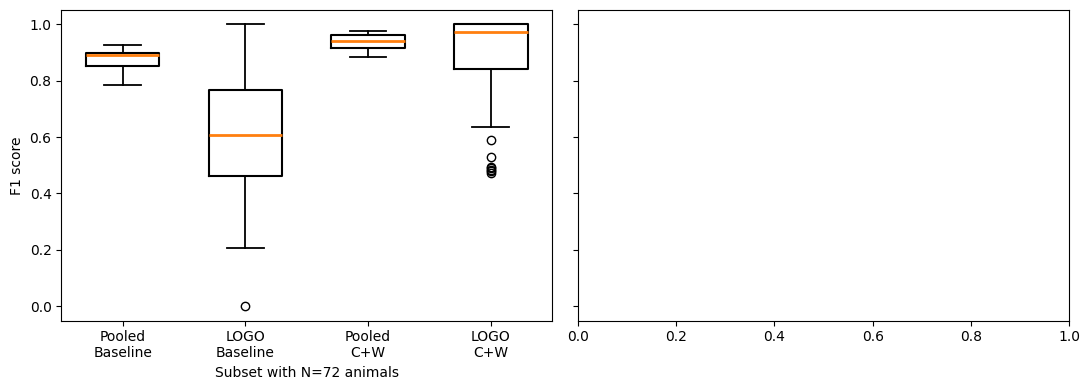

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    ncols=2,
    sharey=True,
    figsize=(11, 4)
)

# ---------- LEFT: Baseline & Weather ----------
data_left = [
    grouped_baseline["F1 Score Global"],
    logo_1_bolus_results["macro_f1"],
    grouped_all_sensors["F1 Score Global"],
    logo_5_bolus_results["macro_f1"],
]

labels_left = [
    "Pooled\nBaseline", "LOGO\nBaseline",
    "Pooled\nC+W", "LOGO\nC+W",
]

axes[0].boxplot(
    data_left,
    widths=0.6,
    patch_artist=False,
    boxprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.3),
    capprops=dict(linewidth=1.3),
    medianprops=dict(linewidth=2),
)

axes[0].set_xticks(range(1, len(labels_left) + 1))
axes[0].set_xticklabels(labels_left)
axes[0].set_xlabel("Subset with N=72 animals")
axes[0].set_ylabel("F1 score")


# # ---------- RIGHT: Bolus Experiments ----------
# data_right = [
#     grouped_baseline["F1 Score Global"],
#     logo_1_bolus_results["macro_f1"],
#     grouped_all_sensors["F1 Score Global"],
#     logo_5_bolus_results["macro_f1"],
# ]

# labels_right = [
#     "Pooled\nBaseline", "LOGO\nBaseline",
#     "Pooled\nC+B+W", "LOGO\nC+B+W",
# ]

# axes[1].boxplot(
#     data_right,
#     widths=0.6,
#     patch_artist=False,
#     boxprops=dict(linewidth=1.5),
#     whiskerprops=dict(linewidth=1.3),
#     capprops=dict(linewidth=1.3),
#     medianprops=dict(linewidth=2),
# )

# axes[1].set_xticks(range(1, len(labels_right) + 1))
# axes[1].set_xticklabels(labels_right)
# axes[1].set_xlabel("Bolus subset")


plt.tight_layout()
plt.show()


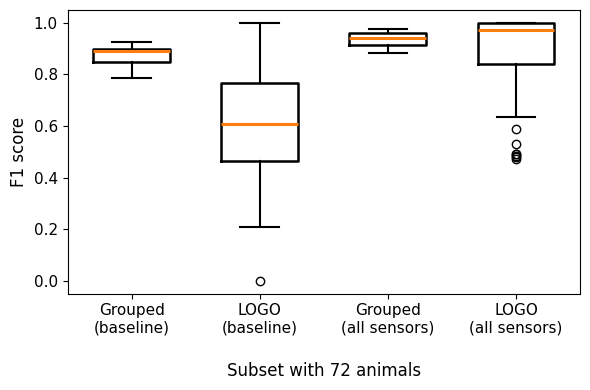

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

data = [
    grouped_baseline["F1 Score Global"],
    logo_1_bolus_results["macro_f1"],
    grouped_all_sensors["F1 Score Global"],
    logo_5_bolus_results["macro_f1"],
]

labels = [
    "Grouped\n(baseline)", "LOGO\n(baseline)",
    "Grouped\n(all sensors)", "LOGO\n(all sensors)",
]

ax.boxplot(
    data,
    widths=0.6,
    patch_artist=False,
    boxprops=dict(linewidth=1.8),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    medianprops=dict(linewidth=2.2),
)

ax.set_xlabel("Subset with N=72 animals", fontsize=12)
ax.set_ylabel("F1 score", fontsize=12)

ax.tick_params(axis='both', labelsize=11)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.set_xlabel("\nSubset with 72 animals")
ax.set_ylabel("F1 score")

plt.tight_layout()
plt.show()

In [19]:
df = pd.read_csv("/Users/luka/priv_projects/moomotion/data/FINAL_merged_collar_herde_weather_bolus.csv")

/var/folders/r_/cnfqbwmx0kn_4s0yzfm9fxdh0000gn/T/ipykernel_31014/3349333885.py:1: DtypeWarning: Columns (8,31,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/luka/priv_projects/moomotion/data/FINAL_merged_collar_herde_weather_bolus.csv")


In [22]:
df.columns.tolist()

['neckband',
 'animal_id',
 'datetime',
 'date',
 'time',
 'behaviour_1',
 'Stehen/Liegen',
 'behaviour_2',
 'comments',
 'Unix_Timestamp',
 'GNSS_Latitude',
 'GNSS_Longitude',
 'Odometer_km',
 'Audio_Stimulus_Count',
 'Pulse_Stimulus_Count',
 'Distance_To_Fence_Max',
 'Distance_To_Fence_Min',
 'IMU_Tick_Count_40mG',
 'IMU_Tick_Count_80mG',
 'IMU_Tick_Count_120mG',
 'IMU_Tick_Count_160mG',
 'IMU_Tick_Count_200mG',
 'IMU_Tick_Count_240mG',
 'Nr.',
 'LOM_X',
 'GEB_DATR',
 'GESCHL_R',
 'Herde',
 'Gewicht 03_07_2024',
 'BCS 03_07_2024',
 'Lahmheit',
 'Kommentar',
 'eShepherd ID',
 'Nr..1',
 'Breed',
 'Geb. Dat',
 'Geschl.',
 'Generation',
 'Gewicht 21.02.2024',
 'BCS (1-5) _21.02.2024',
 'Gewicht 03.07.2024',
 'BCS (1-5)_03.07.2024',
 'Calvig Date2024',
 'TIMESTAMP',
 'RECORD',
 'BattV_Min',
 'BattV_Avg',
 'BattV_Max',
 'PTemp_C_Min',
 'PTemp_C_Avg',
 'PTemp_C_Max',
 'AirT_C_Min',
 'AirT_C_Avg',
 'AirT_C_Max',
 'AirT_C_Std',
 'RelHumid_Min',
 'RelHumid',
 'RelHumid_Max',
 'Rain_mm_Tot',
 '

In [24]:
df[['climate_temp', 'AirT_C_Avg', 'AirT_C_Max']]

,climate_temp,AirT_C_Avg,AirT_C_Max
0,29.96,25.00,25.82
1,29.96,25.00,25.82
2,29.96,25.00,25.82
3,29.96,24.92,25.65
4,29.96,24.92,25.65
...,...,...,...
17556,15.98,12.29,12.47
17557,15.98,12.29,12.47
17558,15.98,12.29,12.47
17559,15.98,12.29,12.47


In [14]:
import joblib

best_model = joblib.load('/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/exp_4_FINAL_merged_collar_herde_weather_bolus/xgboost_seed_46_exp_4_FINAL_merged_collar_herde_weather_bolus.joblib')

In [15]:
best_model.get_booster().feature_names

['IMU_Tick_Count_40mG',
 'IMU_Tick_Count_80mG',
 'IMU_Tick_Count_120mG',
 'IMU_Tick_Count_160mG',
 'IMU_Tick_Count_200mG',
 'IMU_Tick_Count_240mG',
 'act',
 'calving_index',
 'temp',
 'rum_index',
 'temp_normal_index',
 'heat_index',
 'water_intake',
 'Odometer_Diff']

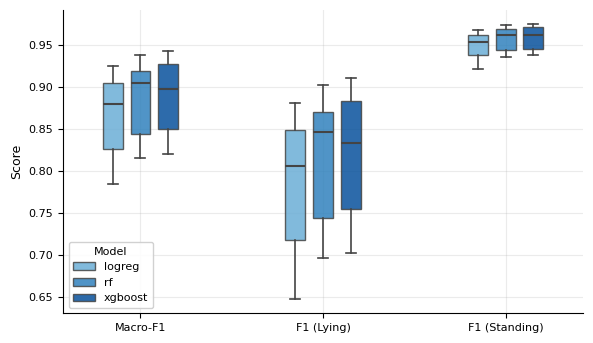

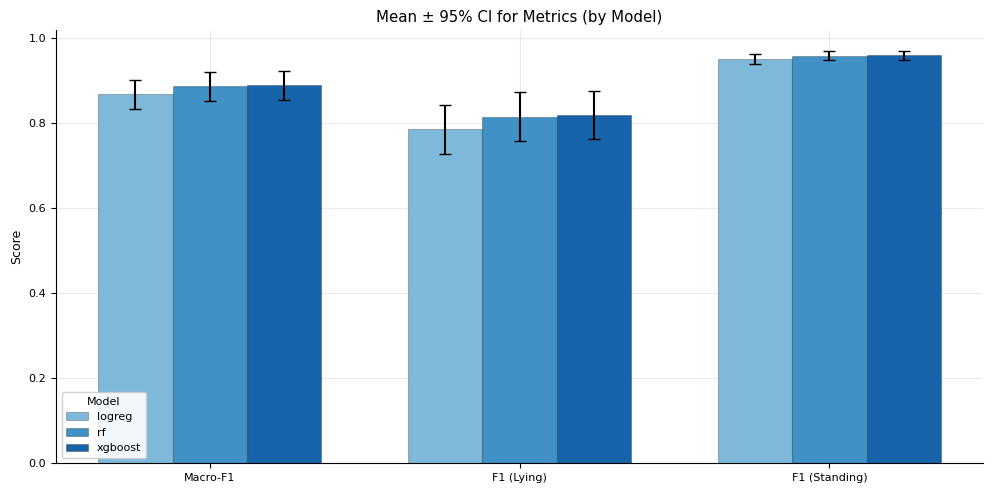

In [40]:
plot_results(baseline_exp_2_results)

In [33]:
lstm_path_5_10 = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/results_lstm_5_10.json"
lstm_path_10_10 = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/results_lstm_10_10.json"
lstm_path_10_30 = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/results_lstm_10_30.json"
lstm_path_10_50 = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/results_lstm_10_50.json"
lstm_path_20_50 = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/results_lstm_20_50.json"
lstm_path_30_50 = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/results_lstm_30_50.json"
lstm_path_40_60 = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/results_lstm_40_60.json"

In [35]:
summarize_results(E)

KeyError: 'rf'

/var/folders/r_/cnfqbwmx0kn_4s0yzfm9fxdh0000gn/T/ipykernel_63262/1443477220.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_data, labels=labels)


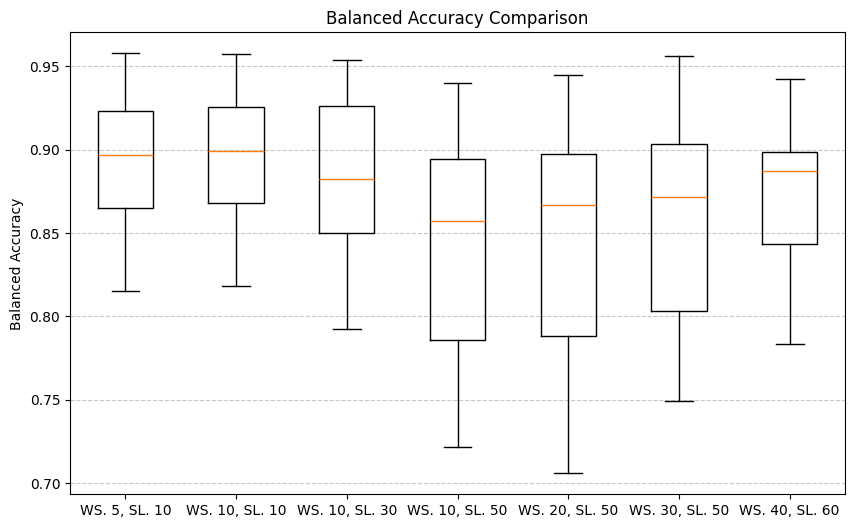

In [9]:
plot_balanced_accuracies(
    [lstm_path_5_10, lstm_path_10_10, lstm_path_10_30, lstm_path_10_50, lstm_path_20_50, lstm_path_30_50, lstm_path_40_60],
    labels=["WS. 5, SL. 10", "WS. 10, SL. 10", "WS. 10, SL. 30", "WS. 10, SL. 50", "WS. 20, SL. 50", "WS. 30, SL. 50", "WS. 40, SL. 60",],
)

In [62]:
baseline_results_path = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/baseline_results.json"
results_path = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/feat_engineering_results.json"
markov_path = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/markov_results.json"
exp_4_path = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/results_exp_4.json"
bolus_baseline_path = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/results_exp_5_baseline_no_markov.json"
bolus_path = "/Users/luka/priv_projects/moomotion/data/results_multiple_splits/results_exp_5.json"



with open(baseline_results_path, "r") as f:
    A = json.load(f)

with open(results_path, "r") as f:
    B = json.load(f)

with open(markov_path, "r") as f:
    C = json.load(f)

with open(exp_4_path, "r") as f:
    D = json.load(f)

with open(lstm_path_10_10, "r") as f:
    E = json.load(f)

with open(bolus_baseline_path, "r") as f:
    bolus_baseline = json.load(f)

with open(bolus_path, "r") as f:
    bolus = json.load(f)


In [41]:
import numpy as np
from scipy import stats

def summarize_results(results: dict):
    # Collect metrics across runs
    balanced_accs = []
    f1_liegen = []
    f1_stehen = []
    f1_macro = []  # average of both classes' F1

    for run_id, run_data in results.items():
        metrics = run_data["Metrics"]["rf"]

        balanced_accs.append(metrics["balanced_accuracy"])
        f1_liegen.append(metrics["F1 Score Liegen"])
        f1_stehen.append(metrics["F1 Score Stehen"])
        f1_macro.append((metrics["F1 Score Liegen"] + metrics["F1 Score Stehen"]) / 2)

    def mean_std_ci(values):
        n = len(values)
        mean = np.mean(values)
        std = np.std(values, ddof=1)  # sample std
        # t critical value for 95% CI
        t_crit = stats.t.ppf(0.975, df=n-1)
        ci_margin = t_crit * std / np.sqrt(n)
        return mean, std, (mean - ci_margin, mean + ci_margin)

    summary = {
        "Balanced Accuracy": mean_std_ci(balanced_accs),
        "F1 (Liegen)": mean_std_ci(f1_liegen),
        "F1 (Stehen)": mean_std_ci(f1_stehen),
        "Macro-F1": mean_std_ci(f1_macro),
    }

    # Pretty print
    for metric, (mean, std, ci) in summary.items():
        print(f"{metric}: {mean:.3f} ± {std:.3f} (95% CI: {ci[0]:.3f} – {ci[1]:.3f})")

    return summary


In [63]:
summarize_results(bolus_baseline)

Balanced Accuracy: 0.872 ± 0.038 (95% CI: 0.845 – 0.899)
F1 (Liegen): 0.801 ± 0.065 (95% CI: 0.755 – 0.847)
F1 (Stehen): 0.953 ± 0.014 (95% CI: 0.943 – 0.963)
Macro-F1: 0.877 ± 0.039 (95% CI: 0.849 – 0.905)


{'Balanced Accuracy': (np.float64(0.871952455603901),
  np.float64(0.038268612481294276),
  (np.float64(0.8445767393828155), np.float64(0.8993281718249865))),
 'F1 (Liegen)': (np.float64(0.8009455523148773),
  np.float64(0.06466560817899117),
  (np.float64(0.7546865629240999), np.float64(0.8472045417056547))),
 'F1 (Stehen)': (np.float64(0.9530520220816205),
  np.float64(0.014054758083944798),
  (np.float64(0.9429978538242751), np.float64(0.9631061903389659))),
 'Macro-F1': (np.float64(0.8769987871982489),
  np.float64(0.03914743058592163),
  (np.float64(0.8489944023769107), np.float64(0.905003172019587)))}

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def prepare_metric_dataframe(results: dict, models=("logreg", "rf", "xgboost")):
    records = []
    for run_id, run_data in results.items():
        metrics_by_model = run_data["Metrics"]

        for model in models:
            if model not in metrics_by_model:
                continue

            metrics = metrics_by_model[model]
            f1_liegen = metrics["F1 Score Liegen"]
            f1_stehen = metrics["F1 Score Stehen"]
            macro_f1 = (f1_liegen + f1_stehen) / 2

            records.append({
                "run": run_id,
                "Model": model,
                "Balanced Accuracy": metrics["balanced_accuracy"],
                "F1 (Lying)": f1_liegen,
                "F1 (Standing)": f1_stehen,
                "Macro-F1": macro_f1
            })

    return pd.DataFrame(records)

def plot_results(results: dict, models=("logreg", "rf", "xgboost")):
    df = prepare_metric_dataframe(results, models=models)
    df_long = df.melt(id_vars=["run", "Model"], var_name="Metric", value_name="Score")

    metrics_order = ["Macro-F1", "F1 (Lying)", "F1 (Standing)"]
    models_order = [m for m in models if m in df["Model"].unique()]

    # Modern, muted model palette for boxplot (distinct, not neon)
    model_colors_box = {
        "logreg": "#6BAED6",
        "rf": "#3182BD",
        "xgboost": "#08519C",
    }

    # Single-hue shades for bar plot (cohesive, not rainbow)
    # If you have 3 models -> 3 progressively darker shades of the same colormap.
    shade_cmap = plt.get_cmap("Blues")
    shade_levels = np.linspace(0.45, 0.80, num=len(models_order))
    model_colors_bar = {m: shade_cmap(lvl) for m, lvl in zip(models_order, shade_levels)}

    # A few styling tweaks for a cleaner look
    plt.rcParams.update({
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "-",
        "axes.axisbelow": True,
        "font.size": 9,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 8,
        })

    # --- 1) Side-by-side boxplots with model colors ---
    plt.figure(figsize=(6, 3.5))
    ax = plt.gca()

    positions, data, box_model_for_each = [], [], []
    tick_positions, tick_labels = [], []

    group_gap = 1.0
    box_gap = 0.28
    pos = 1.0

    for metric in metrics_order:
        start_pos = pos
        for model in models_order:
            vals = df_long[
                (df_long["Metric"] == metric) & (df_long["Model"] == model)
            ]["Score"].dropna().values

            data.append(vals)
            positions.append(pos)
            box_model_for_each.append(model)
            pos += box_gap

        center = (start_pos + (pos - box_gap)) / 2.0
        tick_positions.append(center)
        tick_labels.append(metric)
        pos += group_gap

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.20,
        patch_artist=True,
        showfliers=False,  # often looks cleaner; remove if you want outliers
        medianprops={"linewidth": 1.5},
        whiskerprops={"linewidth": 1.2},
        capprops={"linewidth": 1.2}
    )

    # Color each box by its model
    for box_patch, model in zip(bp["boxes"], box_model_for_each):
        box_patch.set_facecolor(model_colors_box.get(model, "#999999"))
        box_patch.set_alpha(0.85)
        box_patch.set_edgecolor("#444444")
        box_patch.set_linewidth(1.0)

    # Keep lines neutral
    for element in ["whiskers", "caps", "medians"]:
        for line in bp[element]:
            line.set_color("#444444")

    # Legend handles (one per model)
    import matplotlib.patches as mpatches
    handles = [
        mpatches.Patch(facecolor=model_colors_box.get(m, "#999999"), edgecolor="#444444", label=m, alpha=0.85)
        for m in models_order
    ]
    ax.legend(handles=handles, title="Model", loc="best", frameon=True, framealpha=0.9)

    ax.set_title("")
    ax.set_ylabel("Score")
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, ha="center")
    plt.tight_layout()
    plt.show()

    # --- 2) Grouped bar chart: Mean ± 95% CI with single-hue shades ---
    summary = (
        df_long.groupby(["Model", "Metric"])["Score"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    def ci95(row):
        n = int(row["count"])
        if n <= 1 or np.isnan(row["std"]):
            return 0.0
        t_crit = stats.t.ppf(0.975, df=n - 1)
        return float(t_crit * row["std"] / np.sqrt(n))

    summary["ci95"] = summary.apply(ci95, axis=1)

    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    x = np.arange(len(metrics_order))
    bar_width = 0.24 if len(models_order) <= 3 else 0.8 / len(models_order)

    for j, model in enumerate(models_order):
        sub = summary[summary["Model"] == model].set_index("Metric").reindex(metrics_order)
        means = sub["mean"].values
        cis = sub["ci95"].values

        ax.bar(
            x + (j - (len(models_order) - 1) / 2) * bar_width,
            means,
            bar_width,
            yerr=cis,
            capsize=4,
            label=model,
            color=model_colors_bar[model],
            edgecolor=(0, 0, 0, 0.25),
            linewidth=0.8
        )

    ax.set_title("Mean ± 95% CI for Metrics (by Model)")
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_order, ha="center")
    ax.legend(title="Model", loc="best", frameon=True, framealpha=0.9)
    plt.tight_layout()
    plt.show()


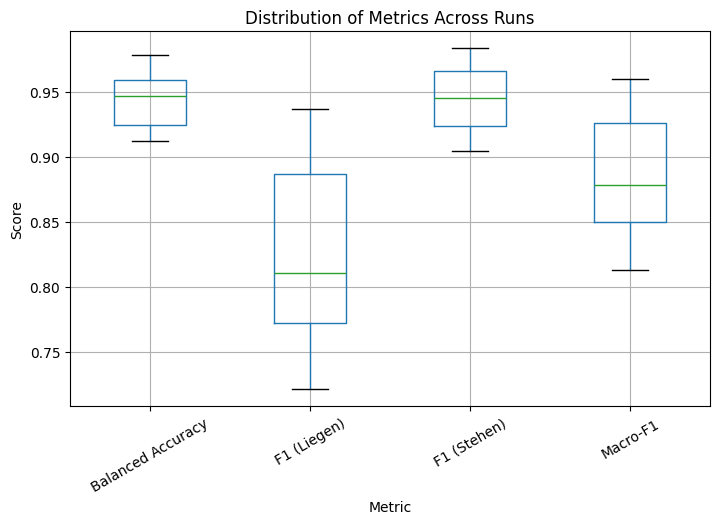

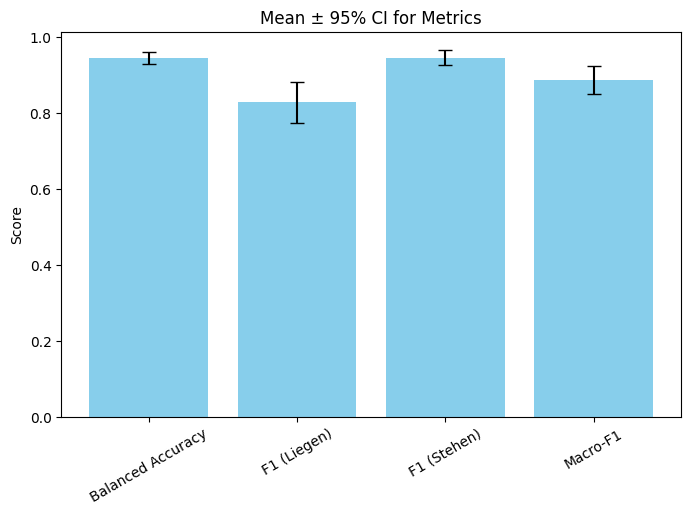

In [49]:
plot_results(bolus)

# Statistical significance

In [52]:
def extract_scores(results, metric, model):
    extracted_scores = []
    for k, v in results.items():
        extracted_scores.append(v['Metrics'][model][metric])

    print(extracted_scores)
    
    return extracted_scores


In [57]:
ba_bolus_baseline = extract_scores(A, 'balanced_accuracy', 'rf')
ba_bolus = extract_scores(B, 'balanced_accuracy', 'rf')

[0.9226347779085727, 0.8825980796640504, 0.8078839729571937, 0.9411723658881624, 0.8766969888033782, 0.848759255143696, 0.9066954967450992, 0.8207619252808473, 0.8693261294352557, 0.9096593313132263]
[0.9202698315896631, 0.9209224295227276, 0.8099610663737145, 0.9508156793849396, 0.8869108609869599, 0.8497606529189524, 0.9433544519381429, 0.8432605319744074, 0.8995709176589661, 0.9484236967958937]


In [55]:
from scipy.stats import ttest_rel

ttest_rel(ba_bolus_baseline, ba_bolus)

TtestResult(statistic=np.float64(-2.542874187908617), pvalue=np.float64(0.03156159349900415), df=np.int64(9))

## Balanced accuracy

In [58]:
ba_A = extract_scores(A, 'balanced_accuracy', 'rf')
ba_B = extract_scores(B, 'balanced_accuracy', 'rf')
ba_C = extract_scores(C, 'balanced_accuracy', 'rf')

[0.9226347779085727, 0.8825980796640504, 0.8078839729571937, 0.9411723658881624, 0.8766969888033782, 0.848759255143696, 0.9066954967450992, 0.8207619252808473, 0.8693261294352557, 0.9096593313132263]
[0.9202698315896631, 0.9209224295227276, 0.8099610663737145, 0.9508156793849396, 0.8869108609869599, 0.8497606529189524, 0.9433544519381429, 0.8432605319744074, 0.8995709176589661, 0.9484236967958937]
[0.9564208509236803, 0.934895057939264, 0.8874258551061088, 0.9750230725838067, 0.9092075106899886, 0.8428364018106745, 0.9509133433621578, 0.8756850642817334, 0.9026046828573175, 0.9514811031664965]


In [10]:
import numpy as np

def cohens_d_paired(x, y):
    """
    Compute Cohen's d for paired samples.
    x, y: arrays of scores from the same subjects/folds
    """
    diff = np.array(y) - np.array(x)
    return diff.mean() / diff.std(ddof=1)


In [11]:
cohens_d_paired(ba_B, ba_D)

np.float64(0.8859692612170255)

In [12]:
cohens_d_paired(ba_B, ba_C)

np.float64(1.6030443558980676)

### Baseline vs. Feature Engineering (40 min)
✅ Statistically significant improvement

In [59]:
from scipy.stats import ttest_rel

ttest_rel(ba_A, ba_B)

TtestResult(statistic=np.float64(-3.588754778381374), pvalue=np.float64(0.005850153664491785), df=np.int64(9))

### Feature engineering without- vs. with Markov Chain postprocessing
✅ Statistically significant improvement

In [60]:
ttest_rel(ba_B, ba_C)

TtestResult(statistic=np.float64(-2.8016808023424833), pvalue=np.float64(0.020655839598192387), df=np.int64(9))

In [9]:
ttest_rel(ba_B, ba_D)

TtestResult(statistic=np.float64(-2.8016808023424833), pvalue=np.float64(0.020655839598192387), df=np.int64(9))

In [ ]:
import numpy as np

def cohens_d_paired(x, y):
    """
    Compute Cohen's d for paired samples.
    x, y: arrays of scores from the same subjects/folds
    """
    diff = np.array(y) - np.array(x)
    return diff.mean() / diff.std(ddof=1)


/var/folders/r_/cnfqbwmx0kn_4s0yzfm9fxdh0000gn/T/ipykernel_52766/1443477220.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_data, labels=labels)


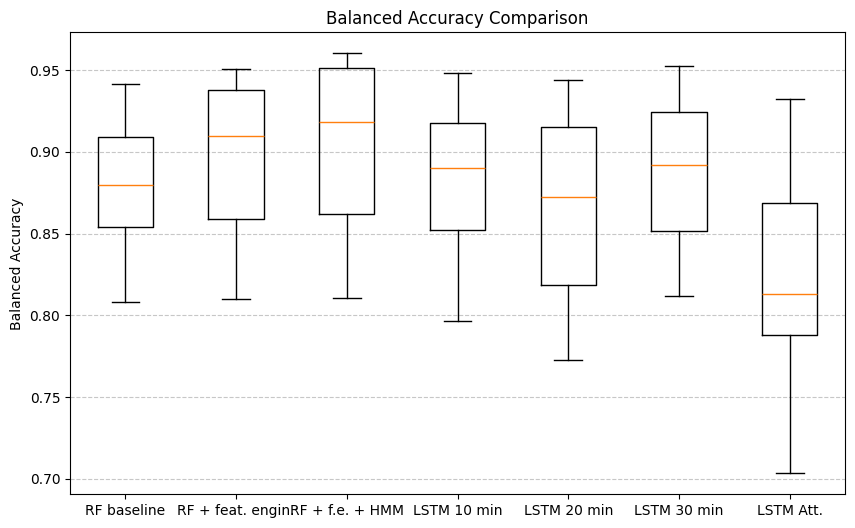

In [33]:
plot_balanced_accuracies(
    [baseline_results_path, results_path, markov_path, lstm_path_10min, lstm_path_30min, lstm_path, lstm_attention],
    labels=["RF baseline", "RF + feat. engin.", "RF + f.e. + HMM", "LSTM 10 min", "LSTM 20 min", "LSTM 30 min", "LSTM Att."],
)

In [18]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_balanced_accuracies(json_paths, labels=None, model_name=None):
    """
    json_paths: list of str - paths to the result JSON files
    labels: list of str - labels for each run (defaults to file names)
    model_name: str - specific model name to plot.
                    If None, will plot for the first available model in each JSON
                    (may differ between files if names differ)
    """
    all_data = []

    for idx, path in enumerate(json_paths):
        with open(path, "r") as f:
            results = json.load(f)

        ba_values = []
        for seed, data in results.items():
            metrics = data.get("Metrics", {})

            if model_name is None:
                # Pick the first model present in THIS JSON
                chosen_model = next(iter(metrics))
            else:
                # If the requested model is missing, try to fall back to another one
                if model_name in metrics:
                    chosen_model = model_name
                else:
                    chosen_model = next(iter(metrics))

            ba = metrics.get(chosen_model, {}).get("balanced_accuracy", None)
            if isinstance(ba, (int, float)):
                ba_values.append(ba)

        all_data.append(ba_values)

    # Default labels: file name without extension
    if labels is None:
        labels = [os.path.splitext(os.path.basename(p))[0] for p in json_paths]

    plt.figure(figsize=(10, 6))
    plt.boxplot(all_data, labels=labels)
    plt.ylabel("Balanced Accuracy")
    plt.title("Balanced Accuracy Comparison")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()


/var/folders/r_/cnfqbwmx0kn_4s0yzfm9fxdh0000gn/T/ipykernel_10820/1443477220.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_data, labels=labels)


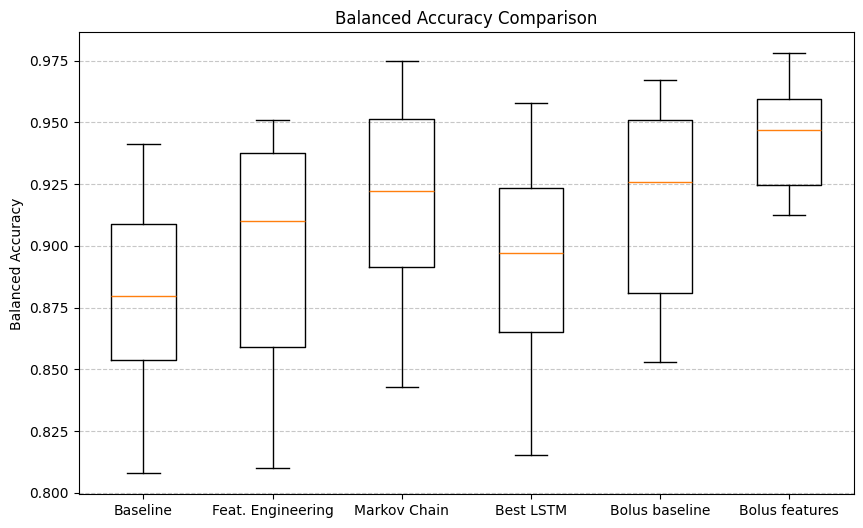

In [51]:
plot_balanced_accuracies(
    [baseline_results_path, results_path, markov_path, lstm_path_5_10, bolus_baseline_path, bolus_path],
    labels=["Baseline", "Feat. Engineering", "Markov Chain", "Best LSTM", "Bolus baseline", "Bolus features"]
)

# Faulty scores

In [61]:
faulty_ids = [
      15570,
      99703,
      29667,
      37448,
      90352,
      99711,
      2462,
      99740,
      21854,
      99747,
      73910,
      37462,
      75433,
      2460,
      2461,
      37451,
      74702,
      29605,
      99718,
      15564,
      37426
    ]

In [5]:
df = pd.read_csv("/Users/luka/priv_projects/moomotion/data/eShepherd_herde_labeled.csv")

In [6]:
test_df = pd.read_pickle("/Users/luka/priv_projects/moomotion/data/models/X_test_seed_44.pkl")
y_pred = pd.read_pickle("/Users/luka/priv_projects/moomotion/data/models/y_pred_seed_44.pkl")
test_df['y_pred'] = y_pred

In [7]:
wrong_predictions = test_df[test_df['Stehen/Liegen']!=test_df['y_pred']]

In [70]:
len(wrong_predictions.animal_id.unique())

17

In [10]:
wrong_predictions.animal_id.value_counts()

animal_id
90352    121
15564     68
99711     59
75433     40
29605     40
21854     34
99703     30
2460      24
74702     20
37426     19
15570     16
2462      14
2461      12
99747      3
99740      3
73910      3
37462      2
Name: count, dtype: Int64

In [19]:
wrong_predictions[wrong_predictions['animal_id']=='37426']

,animal_id,Stehen/Liegen,IMU_Tick_Count_40mG,IMU_Tick_Count_80mG,IMU_Tick_Count_120mG,IMU_Tick_Count_160mG,IMU_Tick_Count_200mG,IMU_Tick_Count_240mG,IMU_TOTAL_WEIGHTED,Odometer_Diff,...,IMU_Tick_Count_80mG_diff_rolling_mean,IMU_Tick_Count_120mG_diff_rolling_sum,IMU_Tick_Count_120mG_diff_rolling_mean,IMU_Tick_Count_160mG_diff_rolling_sum,IMU_Tick_Count_160mG_diff_rolling_mean,IMU_Tick_Count_200mG_diff_rolling_sum,IMU_Tick_Count_200mG_diff_rolling_mean,IMU_Tick_Count_240mG_diff_rolling_sum,IMU_Tick_Count_240mG_diff_rolling_mean,y_pred
22539,37426,0,0.899023,0.778364,0.732862,0.709065,0.692196,0.688511,434.8,0.081513,...,0.828966,0.658072,0.827772,0.667243,0.841943,0.673213,0.851478,0.677593,0.866357,1
22727,37426,0,0.792793,0.728387,0.660365,0.603679,0.521413,0.489292,225.6,0.000000,...,0.410459,0.000000,0.421515,0.000000,0.427070,0.000000,0.431907,0.000000,0.441163,1
22735,37426,0,0.901827,0.831536,0.787128,0.755943,0.716235,0.674423,504.8,0.014953,...,0.612122,0.673293,0.618879,0.667243,0.621772,0.656867,0.620346,0.613467,0.606954,1
22736,37426,0,0.875125,0.802425,0.754771,0.723726,0.664539,0.589224,398.4,0.018682,...,0.564712,0.603052,0.573391,0.606650,0.580948,0.571955,0.568903,0.457001,0.530525,1
22737,37426,0,0.812914,0.717950,0.655355,0.603679,0.568863,0.489292,235.6,0.007484,...,0.370772,0.000000,0.409476,0.000000,0.427070,0.336606,0.479380,0.000000,0.441163,1
22738,37426,0,0.900430,0.813362,0.751797,0.723726,0.678886,0.648266,435.6,0.000000,...,0.562154,0.595793,0.553773,0.606650,0.564333,0.597041,0.564032,0.570939,0.561151,1
22739,37426,0,0.945633,0.885979,0.832814,0.764598,0.712440,0.653801,563.6,0.000000,...,0.629598,0.754725,0.623034,0.682146,0.592291,0.651086,0.581340,0.580238,0.558463,1
22740,37426,0,0.994712,0.980676,0.963387,0.942836,0.922137,0.903881,1379.6,0.007484,...,0.699104,0.937053,0.715277,0.927936,0.716229,0.920126,0.715092,0.909217,0.716536,1
22741,37426,0,0.994712,0.989787,0.977007,0.950143,0.928171,0.901029,1422.8,0.007484,...,0.698279,0.953840,0.717087,0.936656,0.713367,0.927008,0.711131,0.905959,0.706750,1
22742,37426,0,0.996489,0.989787,0.977880,0.958151,0.931699,0.914871,1467.6,0.003744,...,0.691199,0.954907,0.710426,0.946145,0.711492,0.931020,0.706094,0.921719,0.708285,1


In [11]:
imu = ['IMU_Tick_Count_40mG', 'IMU_Tick_Count_80mG', 'IMU_Tick_Count_120mG', 'IMU_Tick_Count_160mG', 'IMU_Tick_Count_200mG', 'IMU_Tick_Count_240mG', "Odometer_km"]
features = ['animal_id'] + ['Stehen/Liegen'] + ['datetime'] + imu

In [20]:
df[df['animal_id']==37426][features]

,animal_id,Stehen/Liegen,datetime,IMU_Tick_Count_40mG,IMU_Tick_Count_80mG,IMU_Tick_Count_120mG,IMU_Tick_Count_160mG,IMU_Tick_Count_200mG,IMU_Tick_Count_240mG,Odometer_km
22538,37426,Liegen,2024-07-09 07:45:00+00:00,85.0,28.0,20.0,12.0,7.0,6.0,2.102
22539,37426,Liegen,2024-07-09 07:46:00+00:00,147.0,70.0,54.0,47.0,42.0,40.0,2.124
22540,37426,Stehen,2024-09-05 06:45:00+00:00,236.0,225.0,213.0,186.0,167.0,146.0,1.129
22541,37426,Stehen,2024-09-05 06:46:00+00:00,233.0,216.0,191.0,149.0,130.0,114.0,1.143
22542,37426,Stehen,2024-09-05 06:47:00+00:00,236.0,225.0,204.0,181.0,142.0,124.0,1.150
...,...,...,...,...,...,...,...,...,...,...
22747,37426,Liegen,2024-09-12 09:11:00+00:00,234.0,212.0,188.0,167.0,136.0,109.0,1.084
22748,37426,Liegen,2024-09-12 09:12:00+00:00,234.0,227.0,210.0,181.0,153.0,129.0,1.088
22749,37426,Liegen,2024-09-12 09:13:00+00:00,234.0,225.0,204.0,180.0,150.0,120.0,1.089
22750,37426,Liegen,2024-09-12 09:14:00+00:00,235.0,233.0,211.0,192.0,170.0,139.0,1.101
